# Test 2: Quadruple-Well KSWGD and DMPS

This notebook keeps the original quadruple-well data generation, parameter values, DMPS update, and KSWGD update. Shared Python modules hold the repeated implementation details.

In [1]:
from dataclasses import replace
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import display

from plotting_utils import setup_plot_style, ensure_dir
setup_plot_style(scale=1.5)
TEST2_SEED = 73
np.random.seed(TEST2_SEED)
random.seed(TEST2_SEED)
torch.manual_seed(TEST2_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TEST2_SEED)

from systems import (
    QuadrupleWellConfig, FourWellPotential,
    generate_quadruple_langevin_trajectory,
    init_quadruple_particles_uniform_outside,
)
from dmps import fit_diffusion_map_dmps_2d, run_diffusion_map_dmps_2d
from kswgd import train_sdmd_solver, sdmd_kernel_spectrum_2d, run_kernel_spectrum_transport_2d
from baseline import (
    mmd_rbf, sliced_wasserstein, particle_well_coverage,
    compute_kl_divergence_kde,
)
from experiment_plots import (
    plot_quad_pair_snapshots, plot_quad_heatmaps, plot_quad_movement_rate,
    plot_quad_well_density_evolution, plot_quad_kl_divergence,
)

cfg = replace(
    QuadrupleWellConfig(),
    n_target=10000, n_particles=3000, n_iter=3000,
    step_size=0.05, dt=0.01, substeps=10, burnin=1000, seed=TEST2_SEED,
)
potential = FourWellPotential(cfg.temperature, a=cfg.a, b=cfg.b, coupling=cfg.coupling)
WELL_CENTERS = FourWellPotential.centers
WELL_RADIUS = 0.4
ALPHA_REPULSIVE = 0.5
DM_SPECTRAL_MODES = 1000
RECORD_INTERVAL = 100
SNAPSHOT_STEPS = [0, 1000, 3000]
WELL_DENSITY_STEPS = [0, 100, 300, 500, 1000, 1500, 2000, 2500, 3000]
KL_STEPS = list(range(0, cfg.n_iter + 1, 100))
ALL_SNAPSHOT_STEPS = sorted(set(SNAPSHOT_STEPS + WELL_DENSITY_STEPS + KL_STEPS))
ensure_dir('figures/quadruple_well')
print(cfg)
print(f'alpha_repulsive={ALPHA_REPULSIVE}, well_radius={WELL_RADIUS}, DM spectral modes={DM_SPECTRAL_MODES}')

QuadrupleWellConfig(n_target=10000, n_particles=3000, n_iter=3000, step_size=0.05, dt=0.01, burnin=1000, substeps=10, temperature=1.0, a=1.0, b=1.0, coupling=0.0, seed=73, bounds=(-2.0, 2.0))
alpha_repulsive=0.5, well_radius=0.4, DM spectral modes=1000


In [2]:

from types import SimpleNamespace
from pathlib import Path
CACHE_PATH = f'data/test_2_quadruple_well_core_cache_seed_{cfg.seed}.npz'
cache = np.load(CACHE_PATH, allow_pickle=False)
X_tar = cache['X_tar']
X_next = cache['X_next']
X_init = cache['X_init']
cache_steps = [int(step) for step in cache['cache_steps']]
dmps = SimpleNamespace(
    final=cache['dmps_snapshots'][-1].copy(),
    snapshots={step: cache['dmps_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
    metrics={
        'steps': cache['dmps_metric_steps'],
        'well_coverage': cache['dmps_well_coverage'],
        'avg_potential': cache['dmps_avg_potential'],
        'movement_rate': cache['dmps_movement_rate'],
    },
)
kswgd = SimpleNamespace(
    final=cache['kswgd_snapshots'][-1].copy(),
    snapshots={step: cache['kswgd_snapshots'][idx].copy() for idx, step in enumerate(cache_steps)},
    metrics={
        'steps': cache['kswgd_metric_steps'],
        'well_coverage': cache['kswgd_well_coverage'],
        'avg_potential': cache['kswgd_avg_potential'],
        'movement_rate': cache['kswgd_movement_rate'],
    },
)
print(f'Loaded cached DMPS/KSWGD core results from {CACHE_PATH}')


Loaded cached DMPS/KSWGD core results from data/test_2_quadruple_well_core_cache_seed_73.npz


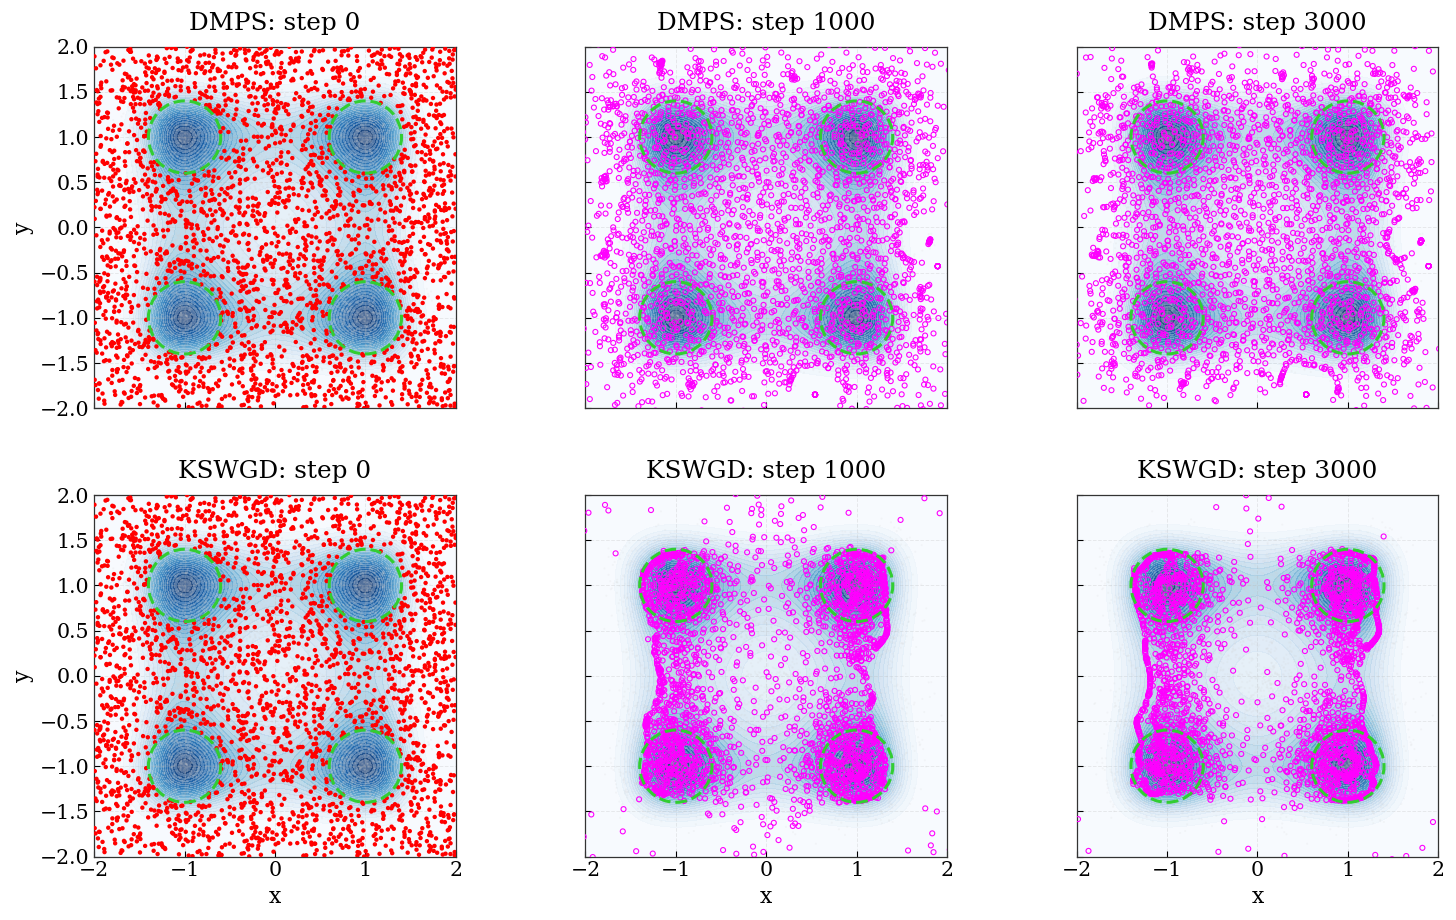

Caption: Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_particle_snapshots.png and figures/quadruple_well/test_2_quadruple_well_particle_snapshots.pdf


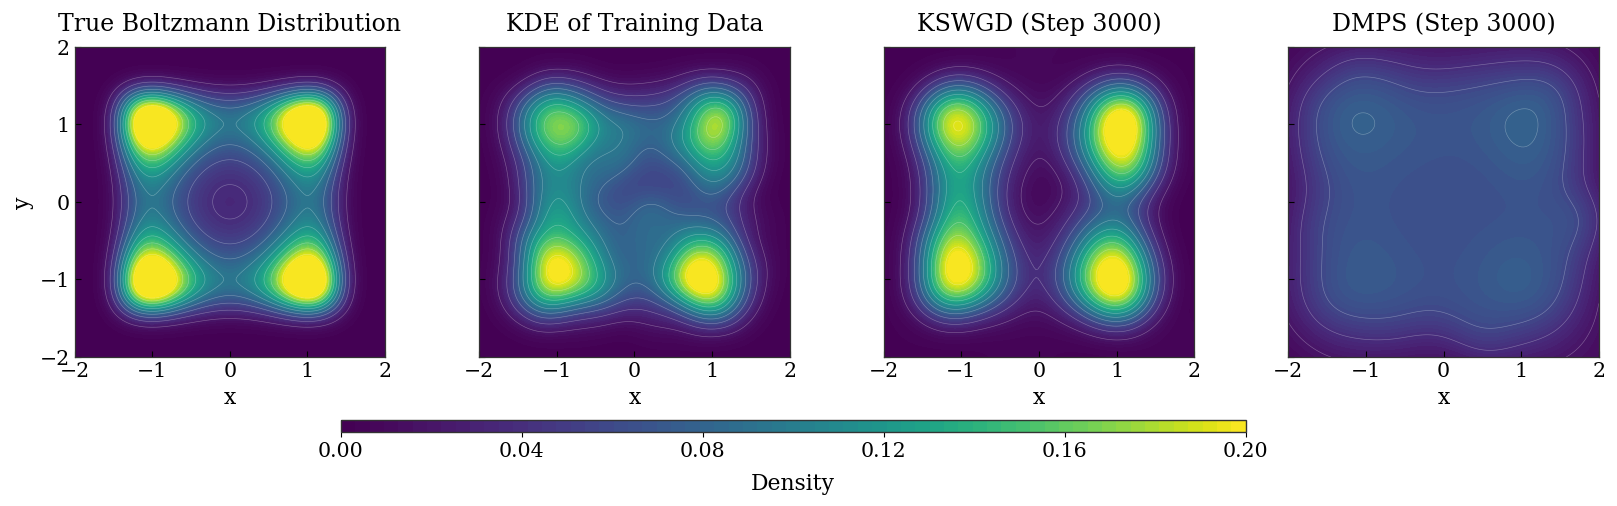

Caption: Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.
Saved: figures/quadruple_well/test_2_quadruple_well_density_heatmaps.png and figures/quadruple_well/test_2_quadruple_well_density_heatmaps.pdf


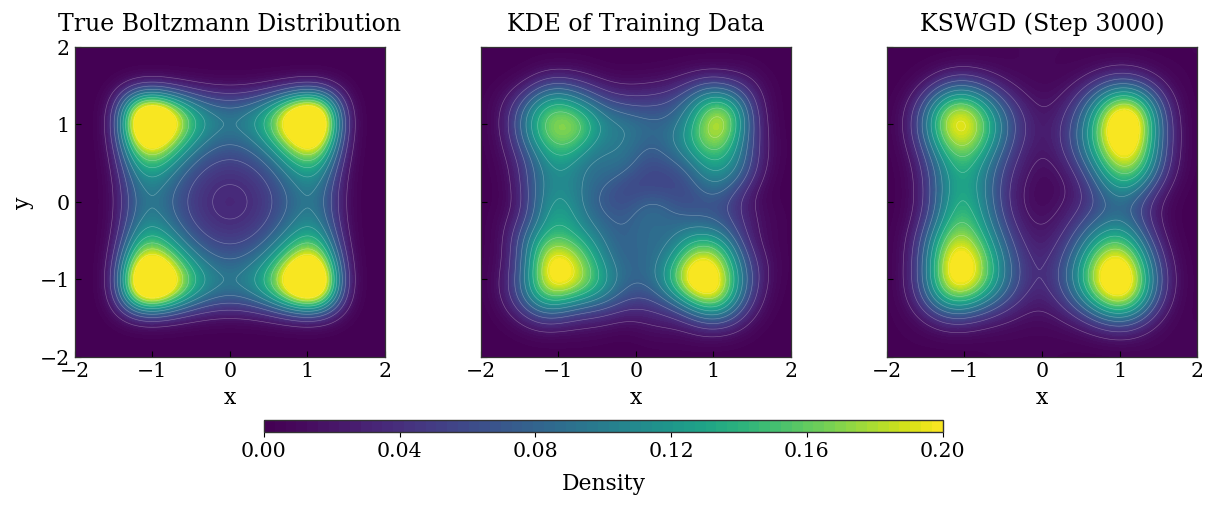

Caption: Three-panel density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, and final KSWGD particles.
Saved: figures/quadruple_well/test_2_quadruple_well_density_heatmaps_1x3.png and figures/quadruple_well/test_2_quadruple_well_density_heatmaps_1x3.pdf


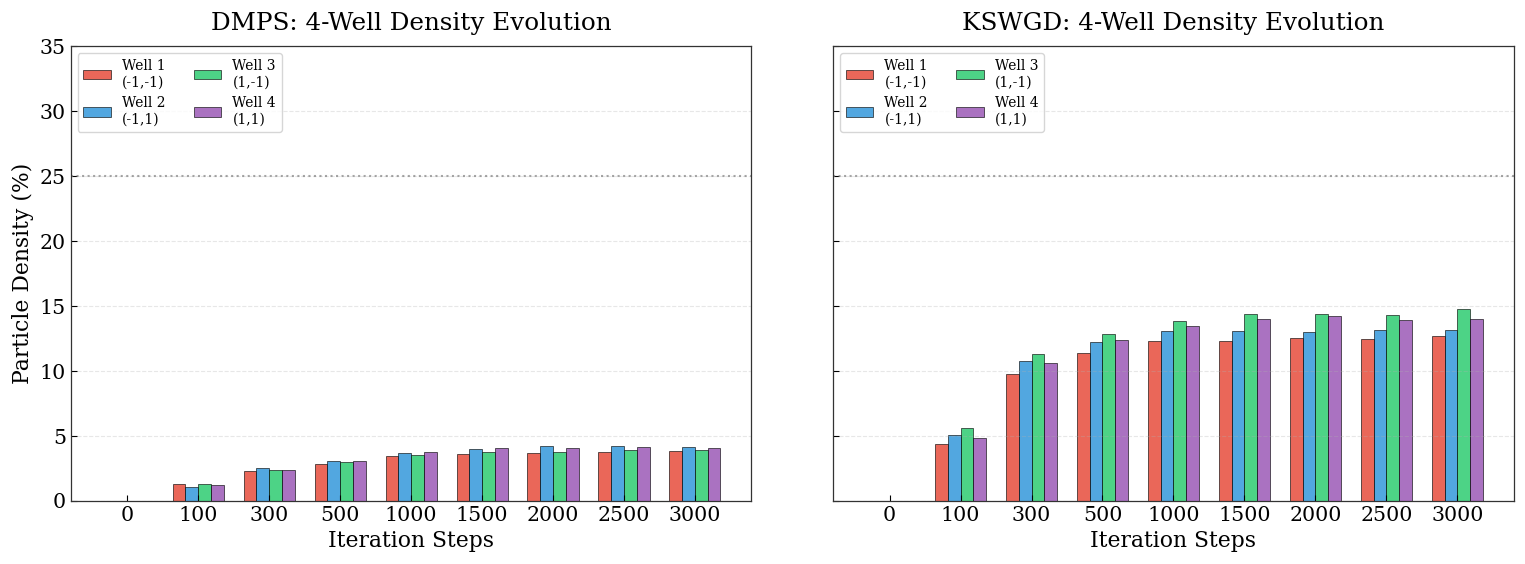

Caption: Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_well_density_evolution.png and figures/quadruple_well/test_2_quadruple_well_well_density_evolution.pdf


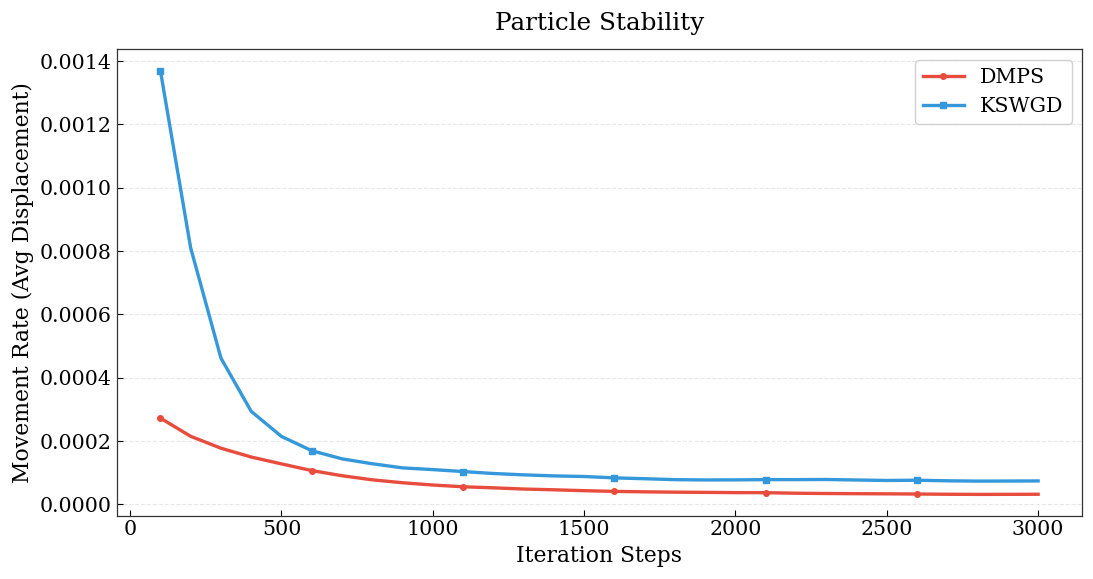

Caption: Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.
Saved: figures/quadruple_well/test_2_quadruple_well_movement_rate.png and figures/quadruple_well/test_2_quadruple_well_movement_rate.pdf
Computing KL divergence curves...


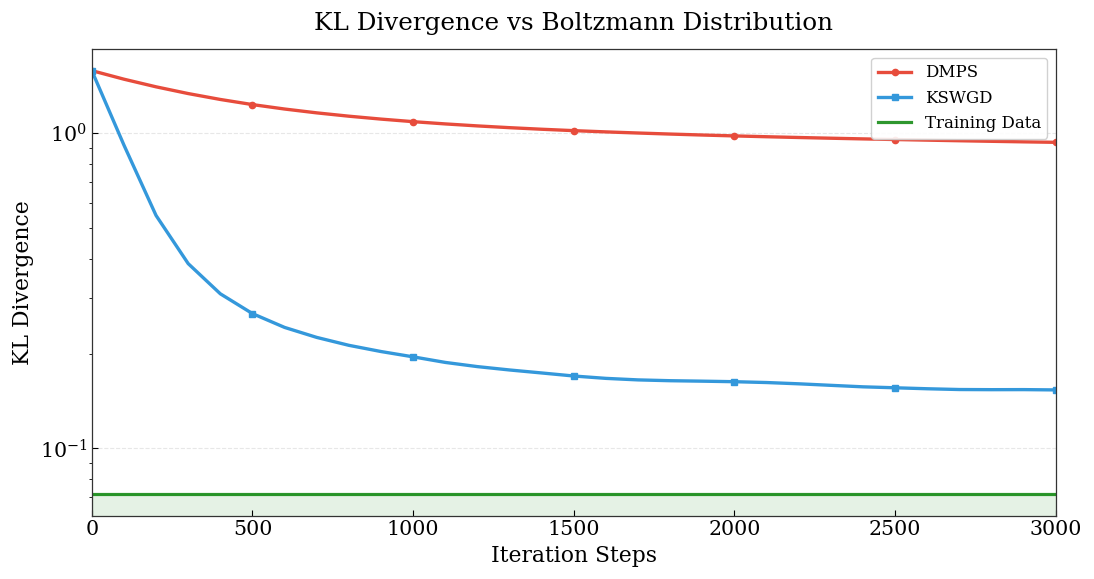

Caption: KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.
Saved: figures/quadruple_well/test_2_quadruple_well_kl_divergence.png and figures/quadruple_well/test_2_quadruple_well_kl_divergence.pdf
Training-data KL: 0.0715
DMPS: initial KL=1.5820, final KL=0.9367
KSWGD: initial KL=1.5820, final KL=0.1534


In [3]:
snapshot_view = {
    'DMPS': {step: dmps.snapshots[step] for step in SNAPSHOT_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in SNAPSHOT_STEPS},
}
plot_quad_pair_snapshots(
    snapshot_view, X_target=X_tar, potential=potential, bounds=cfg.bounds,
    centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_particle_snapshots',
    caption='Quadruple-well particle positions at initialization, 1000 iterations, and 3000 iterations for DMPS and KSWGD.',
)
plot_quad_heatmaps(
    {
        'True Boltzmann Distribution': 'boltzmann',
        'KDE of Training Data': X_tar,
        'KSWGD (Step 3000)': kswgd.final,
        'DMPS (Step 3000)': dmps.final,
    },
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_density_heatmaps',
    vmax_source='True Boltzmann Distribution',
    caption='Density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, KSWGD final particles, and DMPS final particles.',
)
plot_quad_heatmaps(
    {
        'True Boltzmann Distribution': 'boltzmann',
        'KDE of Training Data': X_tar,
        'KSWGD (Step 3000)': kswgd.final,
    },
    potential=potential, bounds=cfg.bounds,
    stem='figures/quadruple_well/test_2_quadruple_well_density_heatmaps_1x3',
    vmax_source='True Boltzmann Distribution',
    caption='Three-panel density heatmap comparison for the quadruple-well Boltzmann law, training trajectory, and final KSWGD particles.',
)
well_density_view = {
    'DMPS': {step: dmps.snapshots[step] for step in WELL_DENSITY_STEPS},
    'KSWGD': {step: kswgd.snapshots[step] for step in WELL_DENSITY_STEPS},
}
plot_quad_well_density_evolution(
    well_density_view, centers=WELL_CENTERS, radius=WELL_RADIUS,
    stem='figures/quadruple_well/test_2_quadruple_well_well_density_evolution',
    caption='Percentage of particles in each of the four wells over iterations for DMPS and KSWGD.',
)
plot_quad_movement_rate(
    {'DMPS': dmps.metrics, 'KSWGD': kswgd.metrics},
    stem='figures/quadruple_well/test_2_quadruple_well_movement_rate',
    caption='Mean particle displacement per recorded step for DMPS and KSWGD in the quadruple-well experiment.',
)

print('Computing KL divergence curves...')
training_kl = compute_kl_divergence_kde(X_tar, potential)
kl_by_method = {}
for name, res in {'DMPS': dmps, 'KSWGD': kswgd}.items():
    values = []
    for step in KL_STEPS:
        values.append(compute_kl_divergence_kde(res.snapshots[step], potential))
    kl_by_method[name] = np.asarray(values)
plot_quad_kl_divergence(
    kl_by_method, KL_STEPS, training_kl=training_kl,
    stem='figures/quadruple_well/test_2_quadruple_well_kl_divergence',
    caption='KL divergence from the true quadruple-well Boltzmann distribution over iterations for DMPS and KSWGD.',
)
print(f'Training-data KL: {training_kl:.4f}')
for name, values in kl_by_method.items():
    print(f'{name}: initial KL={values[0]:.4f}, final KL={values[-1]:.4f}')